## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("patient_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (200020, 17)


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [3]:
df.columns.tolist()

['Patient ID',
 'Heart Rate',
 'Respiratory Rate',
 'Timestamp',
 'Body Temperature',
 'Oxygen Saturation',
 'Systolic Blood Pressure',
 'Diastolic Blood Pressure',
 'Age',
 'Gender',
 'Weight (kg)',
 'Height (m)',
 'Derived_HRV',
 'Derived_Pulse_Pressure',
 'Derived_BMI',
 'Derived_MAP',
 'Risk Category']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Respiratory Rate          200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5   Oxygen Saturation         200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

In [5]:
# Class distribution
print(df['Risk Category'].value_counts())
print()
print(df['Risk Category'].value_counts(normalize=True) * 100)

Risk Category
High Risk    105115
Low Risk      94905
Name: count, dtype: int64

Risk Category
High Risk    52.552245
Low Risk     47.447755
Name: proportion, dtype: float64


## 3. Preprocessing

In [6]:
# Drop non-informative columns (Patient ID, Timestamp)
# KEEP all derived features — they add clinical signal and must be
# consistent between training and inference
df = df.drop(['Patient ID', 'Timestamp'], axis=1)

# Binary label mapping  (Low Risk = 0, High Risk = 1)
df['Risk Category'] = df['Risk Category'].map({'Low Risk': 0, 'High Risk': 1})
print("Label mapping: Low Risk → 0 | High Risk → 1")
print(df['Risk Category'].value_counts())

Label mapping: Low Risk → 0 | High Risk → 1
Risk Category
1    105115
0     94905
Name: count, dtype: int64


In [7]:
# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
print("Gender encoded: Male → 0 | Female → 1")

Gender encoded: Male → 0 | Female → 1


In [8]:
# Fill missing values with median (numeric only)
df = df.fillna(df.median(numeric_only=True))
print("Missing values after fill:")
print(df.isna().sum())

Missing values after fill:
Heart Rate                  0
Respiratory Rate            0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
dtype: int64


## 4. Exploratory Data Analysis

In [9]:
# Correlation with target (numeric cols only — avoids dtype errors)
corr = df.select_dtypes(include='number').corr()['Risk Category'].sort_values(ascending=False)
print(corr)

Risk Category               1.000000
Heart Rate                  0.368487
Derived_BMI                 0.151767
Weight (kg)                 0.024642
Diastolic Blood Pressure    0.003607
Gender                      0.002528
Age                         0.002466
Body Temperature            0.001181
Derived_MAP                 0.000760
Oxygen Saturation          -0.000652
Respiratory Rate           -0.001312
Derived_HRV                -0.001522
Systolic Blood Pressure    -0.003534
Derived_Pulse_Pressure     -0.004936
Height (m)                 -0.091435
Name: Risk Category, dtype: float64


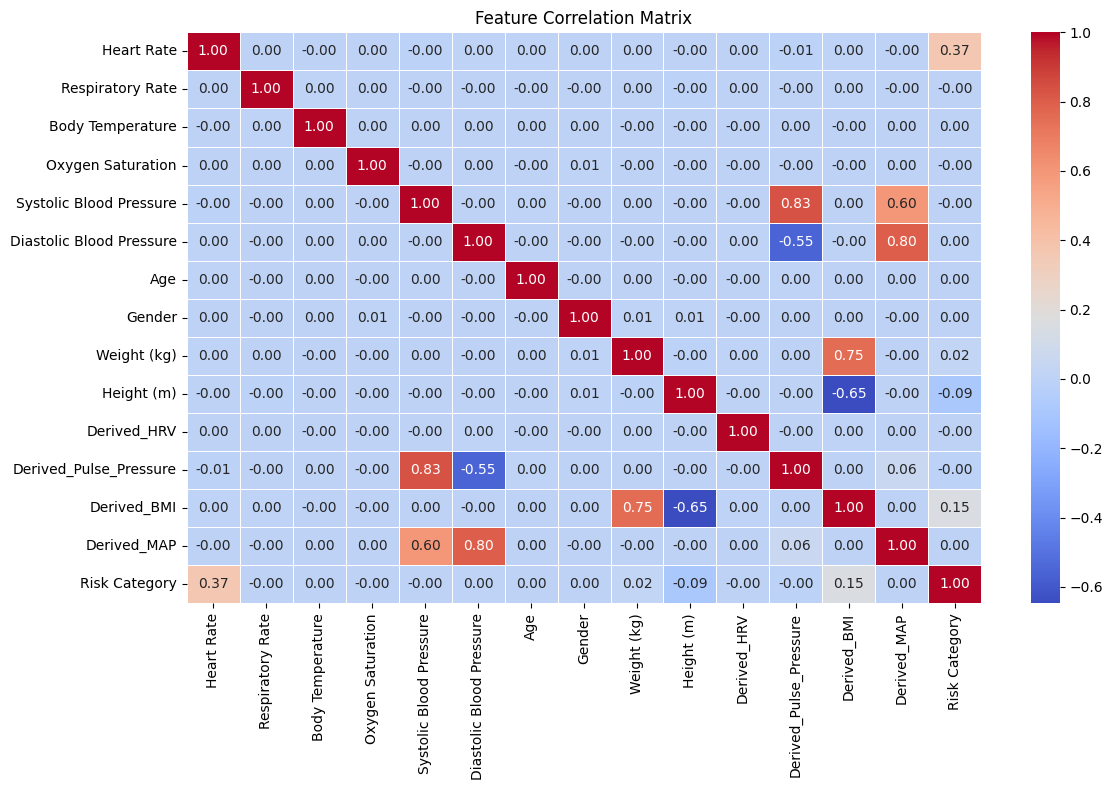

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

In [11]:
X = df.drop(columns=['Risk Category'])
y = df['Risk Category']

# Store training columns for inference consistency check later
TRAIN_COLUMNS = X.columns.tolist()
print("Features used:", TRAIN_COLUMNS)
print("Total features:", len(TRAIN_COLUMNS))

Features used: ['Heart Rate', 'Respiratory Rate', 'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP']
Total features: 14


In [12]:
# FIX: separate validation set so test data is never seen during training
# 70% train | 15% val (early stopping) | 15% test (final evaluation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 140014 samples
Val   : 30003 samples
Test  : 30003 samples


## 6. Handle Class Imbalance

In [13]:
# Compute scale_pos_weight = count(negative) / count(positive)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"Negative (Low Risk) : {neg}")
print(f"Positive (High Risk): {pos}")
print(f"scale_pos_weight    : {spw:.3f}")

Negative (Low Risk) : 66433
Positive (High Risk): 73581
scale_pos_weight    : 0.903


## 7. Model Training

In [14]:
params = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'boosting_type':    'gbdt',
    'num_leaves':       31,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'lambda_l2':        0.1,
    'scale_pos_weight': spw,   # FIX: handles class imbalance
    'verbose':         -1
}

In [15]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)   # FIX: separate val set, NOT test

start_time = time.time()

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],             # FIX: val_data instead of test
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(100)
    ]
)

training_time = time.time() - start_time
print(f"Training time   : {training_time:.2f}s")
print(f"Best iteration  : {model.best_iteration}")  # FIX: log best iteration

Training until validation scores don't improve for 100 rounds
[100]	training's binary_logloss: 0.0108353	valid_1's binary_logloss: 0.0125341
[200]	training's binary_logloss: 0.00121705	valid_1's binary_logloss: 0.00433484
[300]	training's binary_logloss: 0.000447785	valid_1's binary_logloss: 0.00460417
Early stopping, best iteration is:
[226]	training's binary_logloss: 0.000910784	valid_1's binary_logloss: 0.00426666
Training time   : 4.77s
Best iteration  : 226


## 8. Optimal Threshold Selection (on Validation Set)

In [16]:
# FIX: do NOT hardcode 0.5 — find the best threshold using the val set
val_probs = model.predict(X_val)
fpr_v, tpr_v, thresholds_v = roc_curve(y_val, val_probs)

# Youden's J statistic: maximises sensitivity + specificity
j_scores  = tpr_v - fpr_v
best_idx  = np.argmax(j_scores)
best_threshold = thresholds_v[best_idx]

print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"  Sensitivity (TPR): {tpr_v[best_idx]:.4f}")
print(f"  Specificity (1-FPR): {1 - fpr_v[best_idx]:.4f}")

Optimal threshold (Youden's J): 0.5773
  Sensitivity (TPR): 0.9977
  Specificity (1-FPR): 0.9987


## 9. Evaluation on Test Set

In [17]:
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob > best_threshold).astype(int)  # FIX: tuned threshold

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print(f"Threshold  : {best_threshold:.4f}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

Threshold  : 0.5773
Accuracy   : 0.9979
Precision  : 0.9985
Recall     : 0.9975
F1-score   : 0.9980
ROC-AUC    : 1.0000


In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     14236
   High Risk       1.00      1.00      1.00     15767

    accuracy                           1.00     30003
   macro avg       1.00      1.00      1.00     30003
weighted avg       1.00      1.00      1.00     30003



## 10. Visualisations

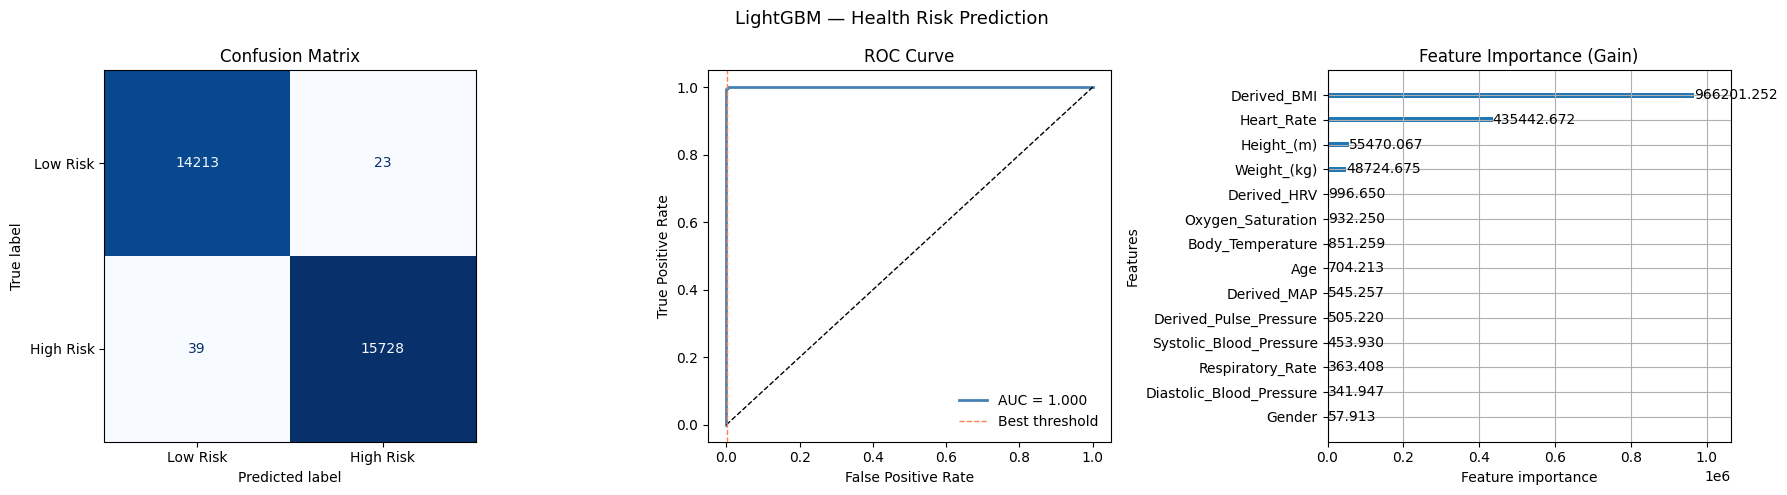

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].axvline(x=fpr[np.argmax(tpr - fpr)], color='coral', ls='--', lw=1, label='Best threshold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(frameon=False)

# ── Feature Importance ──
lgb.plot_importance(model, importance_type='gain', max_num_features=15, ax=axes[2])
axes[2].set_title('Feature Importance (Gain)')

plt.suptitle('LightGBM — Health Risk Prediction', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

## 11. Save & Load Model

In [20]:
model.save_model("patient_risk_model.txt")
print("Model saved as patient_risk_model.txt")
print(f"Optimal threshold to store: {best_threshold:.4f}")

# Save threshold alongside model so inference uses the same value
import json
with open("patient_risk_model_meta.json", "w") as f:
    json.dump({"best_threshold": best_threshold,
               "train_columns": TRAIN_COLUMNS}, f, indent=2)
print("Metadata saved as patient_risk_model_meta.json")

Model saved as patient_risk_model.txt
Optimal threshold to store: 0.5773
Metadata saved as patient_risk_model_meta.json


In [21]:
model_loaded = lgb.Booster(model_file='patient_risk_model.txt')

# Load stored threshold and column order
with open("patient_risk_model_meta.json") as f:
    meta = json.load(f)
loaded_threshold = meta["best_threshold"]
loaded_columns   = meta["train_columns"]
print(f"Loaded model | threshold = {loaded_threshold:.4f}")

Loaded model | threshold = 0.5773


## 12. Inference on New Patients

In [22]:
# FIX: columns must match exactly what the model was trained on
# We keep all derived features here (consistent with training)
new_patients_raw = pd.DataFrame([
    # HR    RR    Temp   SpO2   SBP   DBP  Age  Gender  Wt     Ht    HRV
    [78,   16,   36.7,  97.5,  118,  78,  50,   1,    72.0,  1.72, 0.10],  # Normal
    [105,  25,   38.2,  92.0,  155,  98,  68,   0,    90.0,  1.65, 0.12],  # High-risk signs
    [65,   14,   36.2,  96.0,  112,  70,  30,   1,    65.0,  1.60, 0.09],  # Young, normal
    [92,   20,   37.5,  94.0,  140,  88,  55,   0,    85.0,  1.70, 0.11],  # Borderline
], columns=[
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 'Oxygen Saturation',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age', 'Gender',
    'Weight (kg)', 'Height (m)', 'Derived_HRV'
])

# Recompute derived features (same formulas as training)
new_patients_raw['Derived_Pulse_Pressure'] = (
    new_patients_raw['Systolic Blood Pressure'] - new_patients_raw['Diastolic Blood Pressure'])
new_patients_raw['Derived_BMI'] = (
    new_patients_raw['Weight (kg)'] / new_patients_raw['Height (m)'] ** 2)
new_patients_raw['Derived_MAP'] = (
    new_patients_raw['Diastolic Blood Pressure'] + new_patients_raw['Derived_Pulse_Pressure'] / 3)

# FIX: reorder columns to exactly match training
new_patients = new_patients_raw[loaded_columns]

# Predict using loaded threshold
pred_probs  = model_loaded.predict(new_patients)
pred_labels = ['High Risk' if p > loaded_threshold else 'Low Risk' for p in pred_probs]

for i, (p, label) in enumerate(zip(pred_probs, pred_labels)):
    print(f"Patient {i+1}: {label:12s}  (Probability = {p:.3f})")

Patient 1: Low Risk      (Probability = 0.000)
Patient 2: High Risk     (Probability = 1.000)
Patient 3: Low Risk      (Probability = 0.000)
Patient 4: High Risk     (Probability = 1.000)
